In [1]:
import warnings as wrn
wrn.filterwarnings('ignore', category = DeprecationWarning)
wrn.filterwarnings('ignore', category = FutureWarning)
wrn.filterwarnings('ignore', category = UserWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
import torch
import torch.nn as nn
import random
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
import torch.optim as optim
import torch.nn.functional as F

In [4]:
df = pd.read_csv('Beginner_Reviews_dataset.csv')
df

,Unnamed: 0,sentence,label
0,0,Wow... Loved this place.,1
1,1,Crust is not good.,0
2,2,Not tasty and the texture was just nasty.,0
3,3,Stopped by during the late May bank holiday of...,1
4,4,The selection on the menu was great and so wer...,1
...,...,...,...
995,995,I think food should have flavor and texture an...,0
996,996,Appetite instantly gone.,0
997,997,Overall I was not impressed and would not go b...,0
998,998,"The whole experience was underwhelming, and I ...",0


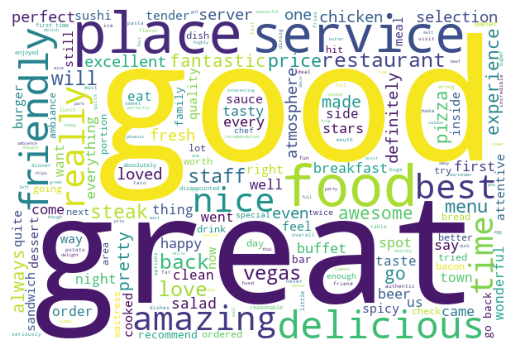

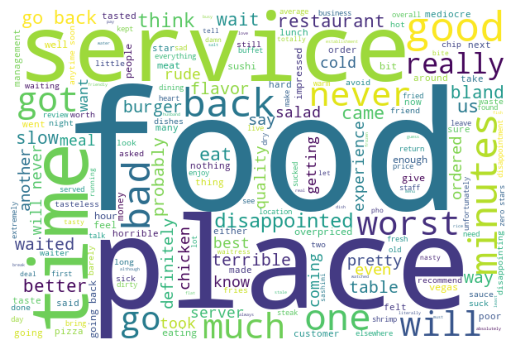

In [9]:
from wordcloud import WordCloud
def visualize(label):
    text = ''
    for msg in df[df['label'] == label]['sentence']:
        msg = msg.lower()
        text += msg + ' '
    wordcloud = WordCloud(width=600, height=400, background_color="white").generate(text)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

visualize(1)
visualize(0)

In [11]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
import re, string
from collections import Counter

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\redcat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\redcat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
example = df.iloc[3]
print('sentence: ', example['sentence'])
print('label: ', example['label'])

sentence:  Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.
label:  1


In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

In [17]:
c_example = clean_text(example['sentence'])
print(c_example)

stopped by during the late may bank holiday off rick steve recommendation and loved it 


In [19]:
cleaned_texts = [clean_text(ex) for ex in df["sentence"]]
tokens = [word_tokenize(t) for t in cleaned_texts]

In [21]:
tokens

[['wow', 'loved', 'this', 'place'],
 ['crust', 'is', 'not', 'good'],
 ['not', 'tasty', 'and', 'the', 'texture', 'was', 'just', 'nasty'],
 ['stopped',
  'by',
  'during',
  'the',
  'late',
  'may',
  'bank',
  'holiday',
  'off',
  'rick',
  'steve',
  'recommendation',
  'and',
  'loved',
  'it'],
 ['the',
  'selection',
  'on',
  'the',
  'menu',
  'was',
  'great',
  'and',
  'so',
  'were',
  'the',
  'prices'],
 ['now',
  'i',
  'am',
  'getting',
  'angry',
  'and',
  'i',
  'want',
  'my',
  'damn',
  'pho'],
 ['honeslty', 'it', 'didn', 't', 'taste', 'that', 'fresh'],
 ['the',
  'potatoes',
  'were',
  'like',
  'rubber',
  'and',
  'you',
  'could',
  'tell',
  'they',
  'had',
  'been',
  'made',
  'up',
  'ahead',
  'of',
  'time',
  'being',
  'kept',
  'under',
  'a',
  'warmer'],
 ['the', 'fries', 'were', 'great', 'too'],
 ['a', 'great', 'touch'],
 ['service', 'was', 'very', 'prompt'],
 ['would', 'not', 'go', 'back'],
 ['the',
  'cashier',
  'had',
  'no',
  'care',
  'wha

In [23]:
counter = Counter()
for tok_list in tokens:
    counter.update(tok_list)

In [25]:
vocab_size = len(counter)
print(f"Кількість унікальних слів у train-наборі: {vocab_size:,}")

Кількість унікальних слів у train-наборі: 2,021


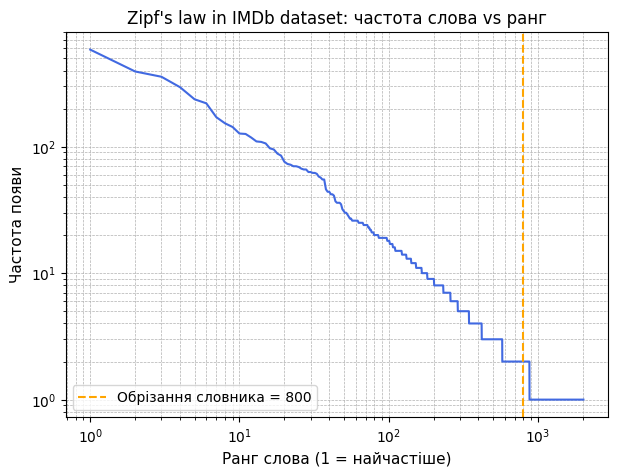

In [27]:
word_freqs = np.array(sorted(counter.values(), reverse=True))
ranks = np.arange(1, len(word_freqs) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, word_freqs, color='royalblue')
plt.title("Zipf's law in IMDb dataset: частота слова vs ранг", fontsize=12)
plt.xlabel("Ранг слова (1 = найчастіше)", fontsize=11)
plt.ylabel("Частота появи", fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)

 # обмежимо словник
MAX_VOCAB = 800
plt.axvline(MAX_VOCAB, color='orange', linestyle='--', label=f'Обрізання словника = {MAX_VOCAB}')
plt.legend()

plt.show()

In [29]:
specials = ["[PAD]", "[UNK]"]
most_common = counter.most_common(MAX_VOCAB - len(specials))
itos = specials + [w for w, _ in most_common]       # index → string
stoi = {w: i for i, w in enumerate(itos)}           # string → index

PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

print("Розмір словника:", len(stoi))
print("Приклад індексу:", stoi.get("food", UNK_IDX))

Розмір словника: 800
Приклад індексу: 12


In [31]:
def encode(tokens):
    return [stoi.get(t, UNK_IDX) for t in tokens]

encoded_texts = [encode(tok_list) for tok_list in tokens]
print(df["sentence"].iloc[1])
print(encoded_texts[0][:20])

Crust is not good.
[422, 168, 10, 16]


In [33]:
maximum = 0
for i in range(999):
    temp = len(encoded_texts[i])
    if temp > maximum:
        maximum = temp
print(maximum)

32


In [35]:
MAX_LEN = 16   # довжина послідовності
def pad_sequence(seq):
    seq = seq[:MAX_LEN] + [PAD_IDX] * max(0, MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)

In [37]:
X = torch.stack([pad_sequence(seq) for seq in encoded_texts])
print(X.shape)   # [N, MAX_LEN]

torch.Size([1000, 16])


In [39]:
y = torch.tensor([ex for ex in df["label"]], dtype=torch.float32)
print(y.shape)

torch.Size([1000])


In [107]:
from torch.utils.data import Dataset, random_split
dataset = TensorDataset(X, y)

# розділяємо на train/val
VAL_FRAC = 0.2
val_sz = int(len(dataset) * VAL_FRAC)
train_sz = len(dataset) - val_sz
train_ds, val_ds = random_split(dataset, [train_sz, val_sz],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

In [109]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    train_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(loader)

    return train_loss


In [111]:
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    valid_loss = 0.0

    with torch.no_grad():
      for x, y in loader:
          x, y = x.to(device), y.to(device)
          out = model(x)
          loss = criterion(out, y)
          valid_loss += loss.item()
    valid_loss /= len(loader)

    return valid_loss

In [113]:
class LSTM_classifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropoutLayer = nn.Dropout()
        
    def forward(self, x):
        x = self.embedding(x)
        out, (h, c) = self.lstm(x)
        h_fwd = h[-2, :, :]
        h_bwd = h[-1, :, :]
        h_cat = torch.cat([h_fwd, h_bwd], dim=1)
        h_cat = self.dropoutLayer(h_cat)
        logits = self.fc(h_cat)
        return logits.squeeze(1) 

In [115]:
vocab_size = len(stoi)
emb_dim = 16
hidden_dim = 64
pad_idx = stoi["[PAD]"]

model_basic = LSTM_classifier(vocab_size, emb_dim, hidden_dim, pad_idx).to(device)
print(model_basic)

LSTM_classifier(
  (embedding): Embedding(800, 16, padding_idx=0)
  (lstm): LSTM(16, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropoutLayer): Dropout(p=0.5, inplace=False)
)


In [117]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=1e-3)

In [119]:
n_epochs = 10

for epoch in range(n_epochs):
   train_loss = train_one_epoch(model_basic, train_loader, optimizer, criterion, device)
   val_loss = evaluate_one_epoch(model_basic, val_loader, criterion, device)

   print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

[01] train_loss=0.6929 | val_loss=0.6932
[02] train_loss=0.6894 | val_loss=0.6904
[03] train_loss=0.6815 | val_loss=0.6838
[04] train_loss=0.6692 | val_loss=0.6683
[05] train_loss=0.6382 | val_loss=0.6374
[06] train_loss=0.5963 | val_loss=0.6196
[07] train_loss=0.5582 | val_loss=0.5914
[08] train_loss=0.5364 | val_loss=0.5802
[09] train_loss=0.4892 | val_loss=0.5825
[10] train_loss=0.4623 | val_loss=0.5726


In [121]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        total_loss += loss.item() * xb.size(0)
        total_acc  += (preds == yb.long()).sum().item()
        n += xb.size(0)
    return total_loss/n, total_acc/n

In [123]:
test_loss, test_acc = evaluate(model_basic, val_loader, criterion, device)
print(f"TEST  loss={test_loss:.4f}  acc={test_acc*100:.2f}%")

TEST  loss=0.5891  acc=68.00%


In [125]:
def load_glove_txt(path):
    vectors = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            vectors[word] = vec
    dim = len(next(iter(vectors.values())))
    return vectors, dim

glove_path = "glove.6B.100d.txt"
glove, emb_dim = load_glove_txt(glove_path)
print("GloVe dim:", emb_dim, "| entries:", len(glove))

GloVe dim: 100 | entries: 400000


In [127]:
for w in ["service", "food", "good", "worst"]:
    print(w, glove[w][:10])

service [-0.4224   -0.13313  -0.41418  -0.23677   0.19041  -0.32738  -0.23698
  0.57607  -0.072985  0.035825]
food [-0.16486    0.91997    0.22737   -0.49031   -0.0018082 -0.33803
  0.057221   0.14601    0.40202   -0.28858  ]
good [-0.030769  0.11993   0.53909  -0.43696  -0.73937  -0.15345   0.081126
 -0.38559  -0.68797  -0.41632 ]
worst [ 0.10823  0.53741  0.885   -0.30311 -0.58348 -0.19097 -0.33086 -0.37934
 -0.24386  0.12135]


In [129]:
vocab_size = len(stoi)
PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

emb_matrix = np.random.normal(scale=0.1, size=(vocab_size, emb_dim)).astype(np.float32)
emb_matrix[PAD_IDX] = 0.0

hit = 0
for w, idx in stoi.items():
    v = glove.get(w)
    if v is not None:
        emb_matrix[idx] = v
        hit += 1
print(f"Coverage: {hit}/{vocab_size} = {hit/vocab_size:.1%}")

Coverage: 797/800 = 99.6%


In [131]:
pretrained_emb = nn.Embedding.from_pretrained(
    torch.tensor(emb_matrix),
    freeze=True,
    padding_idx=PAD_IDX
).to(device)
emb_dim= 100
model_tl = LSTM_classifier(vocab_size, emb_dim, hidden_dim, pad_idx).to(device)
model_tl.embedding = pretrained_emb

In [133]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_tl.parameters(), lr=1e-3)

In [135]:
n_epochs = 9

for epoch in range(n_epochs):
   train_loss = train_one_epoch(model_tl, train_loader, optimizer, criterion, device)
   val_loss = evaluate_one_epoch(model_tl, val_loader, criterion, device)

   print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

[01] train_loss=0.6889 | val_loss=0.6852
[02] train_loss=0.6670 | val_loss=0.6709
[03] train_loss=0.6365 | val_loss=0.6345
[04] train_loss=0.5893 | val_loss=0.6209
[05] train_loss=0.5351 | val_loss=0.5533
[06] train_loss=0.4859 | val_loss=0.5018
[07] train_loss=0.4576 | val_loss=0.5011
[08] train_loss=0.4224 | val_loss=0.5356
[09] train_loss=0.3786 | val_loss=0.4651


In [137]:
test_loss, test_acc = evaluate(model_tl, val_loader, criterion, device)
print(f"TEST  loss={test_loss:.4f}  acc={test_acc*100:.2f}%")

TEST  loss=0.4605  acc=78.50%
